In [1]:
# ==========================================
# Import Libraries
# ==========================================

# Dataset
import kagglehub
import os
import random

# Image Processing
import cv2
from PIL import Image

# Visualization
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import transforms
from torchvision import models
from torchvision.datasets import ImageFolder

from torch.utils.data import (
    DataLoader,
    random_split
)

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve
)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
# ==========================================
# Dataset Download
# ==========================================


# Download latest version
path = kagglehub.dataset_download(
    "shaunthesheep/microsoft-catsvsdogs-dataset"
)

print("Dataset Path:")
print(path)

print("\nFolders in Dataset:")
print(os.listdir(path))

Dataset Path:
C:\Users\User\.cache\kagglehub\datasets\shaunthesheep\microsoft-catsvsdogs-dataset\versions\1

Folders in Dataset:
['MSR-LA - 3467.docx', 'PetImages', 'readme[1].txt']


In [3]:
# ==========================================
# Dataset Inspection
# ==========================================


dataset_dir = os.path.join(path, "PetImages")

# Class names
classes = os.listdir(dataset_dir)

print("Class Names:")
print(classes)

print("\nNumber of Classes:")
print(len(classes))

print("\nDataset Structure:")

for class_name in classes:
    class_path = os.path.join(dataset_dir, class_name)

    image_count = len(os.listdir(class_path))

    print(f"{class_name}: {image_count} images")

Class Names:
['Cat', 'Dog']

Number of Classes:
2

Dataset Structure:
Cat: 12499 images
Dog: 12499 images


Total Images: 24998


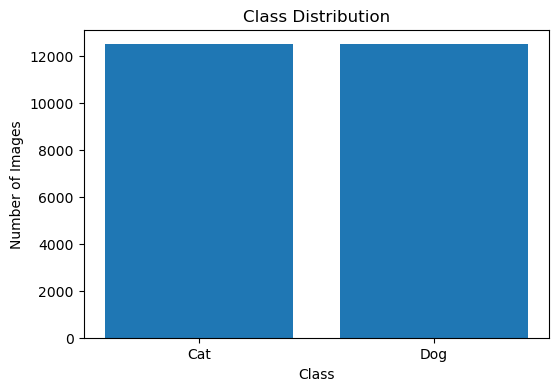

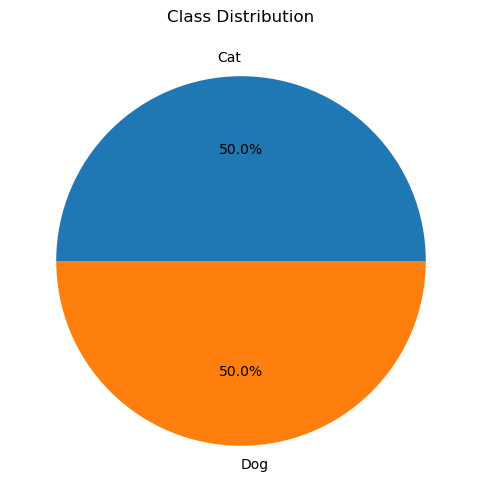

In [4]:
# ==========================================
# Dataset Overview
# ==========================================


cat_count = len(os.listdir(os.path.join(dataset_dir, "Cat")))
dog_count = len(os.listdir(os.path.join(dataset_dir, "Dog")))

total_images = cat_count + dog_count

print("Total Images:", total_images)

# ==========================================
# Class Distribution - Bar Chart
# ==========================================

plt.figure(figsize=(6,4))
plt.bar(["Cat", "Dog"], [cat_count, dog_count])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

# ==========================================
# Class Distribution - Pie Chart
# ==========================================

plt.figure(figsize=(6,6))
plt.pie(
    [cat_count, dog_count],
    labels=["Cat", "Dog"],
    autopct="%1.1f%%"
)
plt.title("Class Distribution")
plt.show()

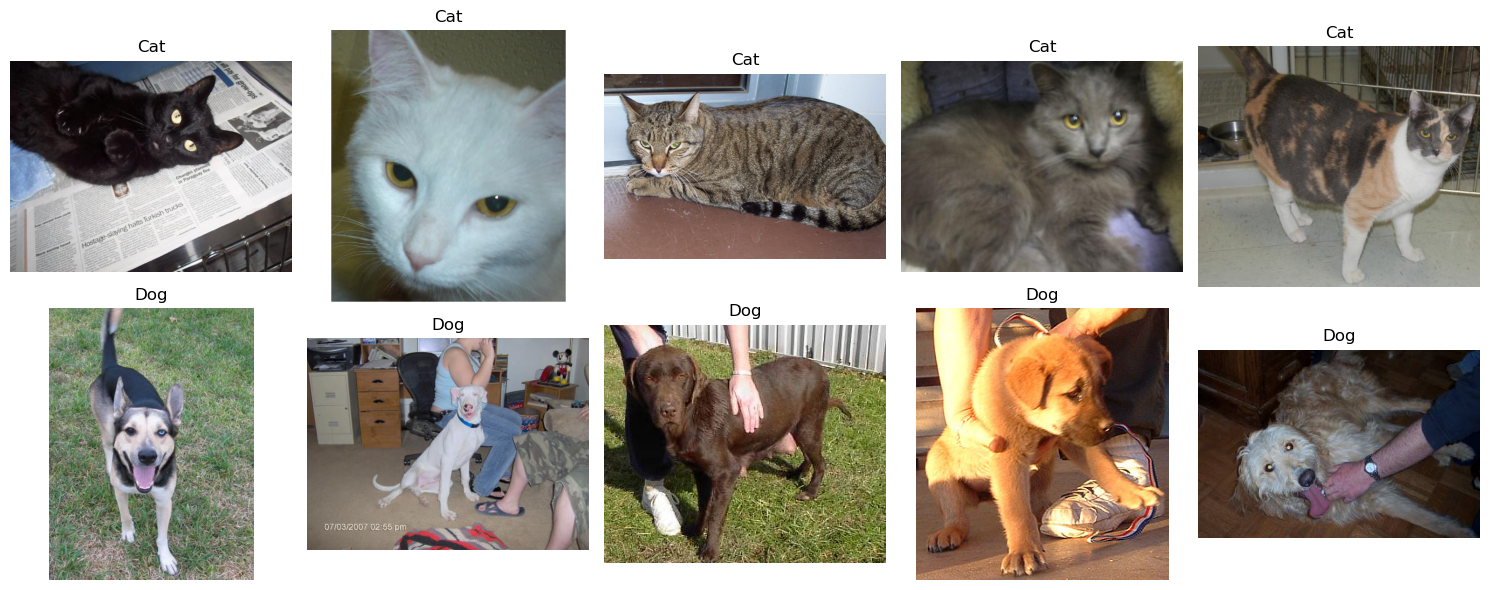

In [5]:
# ==========================================
# Random Cat and Dog Images
# ==========================================



cat_folder = os.path.join(dataset_dir, "Cat")
dog_folder = os.path.join(dataset_dir, "Dog")

# Random images
cat_images = random.sample(os.listdir(cat_folder), 5)
dog_images = random.sample(os.listdir(dog_folder), 5)

plt.figure(figsize=(15,6))

# Cats
for i, img_name in enumerate(cat_images):
    img_path = os.path.join(cat_folder, img_name)
    img = Image.open(img_path)

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title("Cat")
    plt.axis("off")

# Dogs
for i, img_name in enumerate(dog_images):
    img_path = os.path.join(dog_folder, img_name)
    img = Image.open(img_path)

    plt.subplot(2,5,i+6)
    plt.imshow(img)
    plt.title("Dog")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# ==========================================
# Corrupted Image Check
# ==========================================



corrupted_images = []

for class_name in ["Cat", "Dog"]:

    folder = os.path.join(dataset_dir, class_name)

    for img_name in os.listdir(folder):

        img_path = os.path.join(folder, img_name)

        try:
            img = Image.open(img_path)
            img.verify()

        except:
            corrupted_images.append(img_path)

print("Total Corrupted Images:", len(corrupted_images))

if len(corrupted_images) > 0:
    print("\nSample Corrupted Images:")
    
    for img in corrupted_images[:10]:
        print(img)

Total Corrupted Images: 0


c:\Users\User\OneDrive\Documents\anaconda\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [7]:
# ==========================================
# Blur Image Check
# ==========================================



blur_count = 0

for class_name in ["Cat", "Dog"]:

    folder = os.path.join(dataset_dir, class_name)

    sample_images = random.sample(os.listdir(folder), 100)

    for img_name in sample_images:

        try:
            img_path = os.path.join(folder, img_name)

            img = cv2.imread(img_path)

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            blur_value = cv2.Laplacian(gray, cv2.CV_64F).var()

            if blur_value < 100:
                blur_count += 1

        except:
            pass

print("Blurred Images Found:", blur_count)

Blurred Images Found: 18


In [8]:
# ==========================================
# Remove Corrupted Images
# ==========================================



bad_files = [
    os.path.join(dataset_dir, "Cat", "666.jpg"),
    os.path.join(dataset_dir, "Cat", "Thumbs.db"),
    os.path.join(dataset_dir, "Dog", "11702.jpg"),
    os.path.join(dataset_dir, "Dog", "Thumbs.db")
]

removed = 0

for file in bad_files:
    if os.path.exists(file):
        os.remove(file)
        removed += 1

print("Removed Files:", removed)

Removed Files: 0


In [9]:
# ==========================================
# Dataset Verification
# ==========================================


cat_count = len(os.listdir(os.path.join(dataset_dir, "Cat")))
dog_count = len(os.listdir(os.path.join(dataset_dir, "Dog")))

print("Cat Images :", cat_count)
print("Dog Images :", dog_count)
print("Total Images :", cat_count + dog_count)

Cat Images : 12499
Dog Images : 12499
Total Images : 24998


In [10]:
# ==========================================
# Data Preprocessing
# ==========================================



# Training Transformations
train_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    # Rotation
    transforms.RandomRotation(20),

    # Horizontal Flip
    transforms.RandomHorizontalFlip(),

    # Zoom + Shift
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),   # Shift
        scale=(0.9, 1.1)        # Zoom
    ),

    # Brightness Adjustment
    transforms.ColorJitter(
        brightness=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation/Test Transformations
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


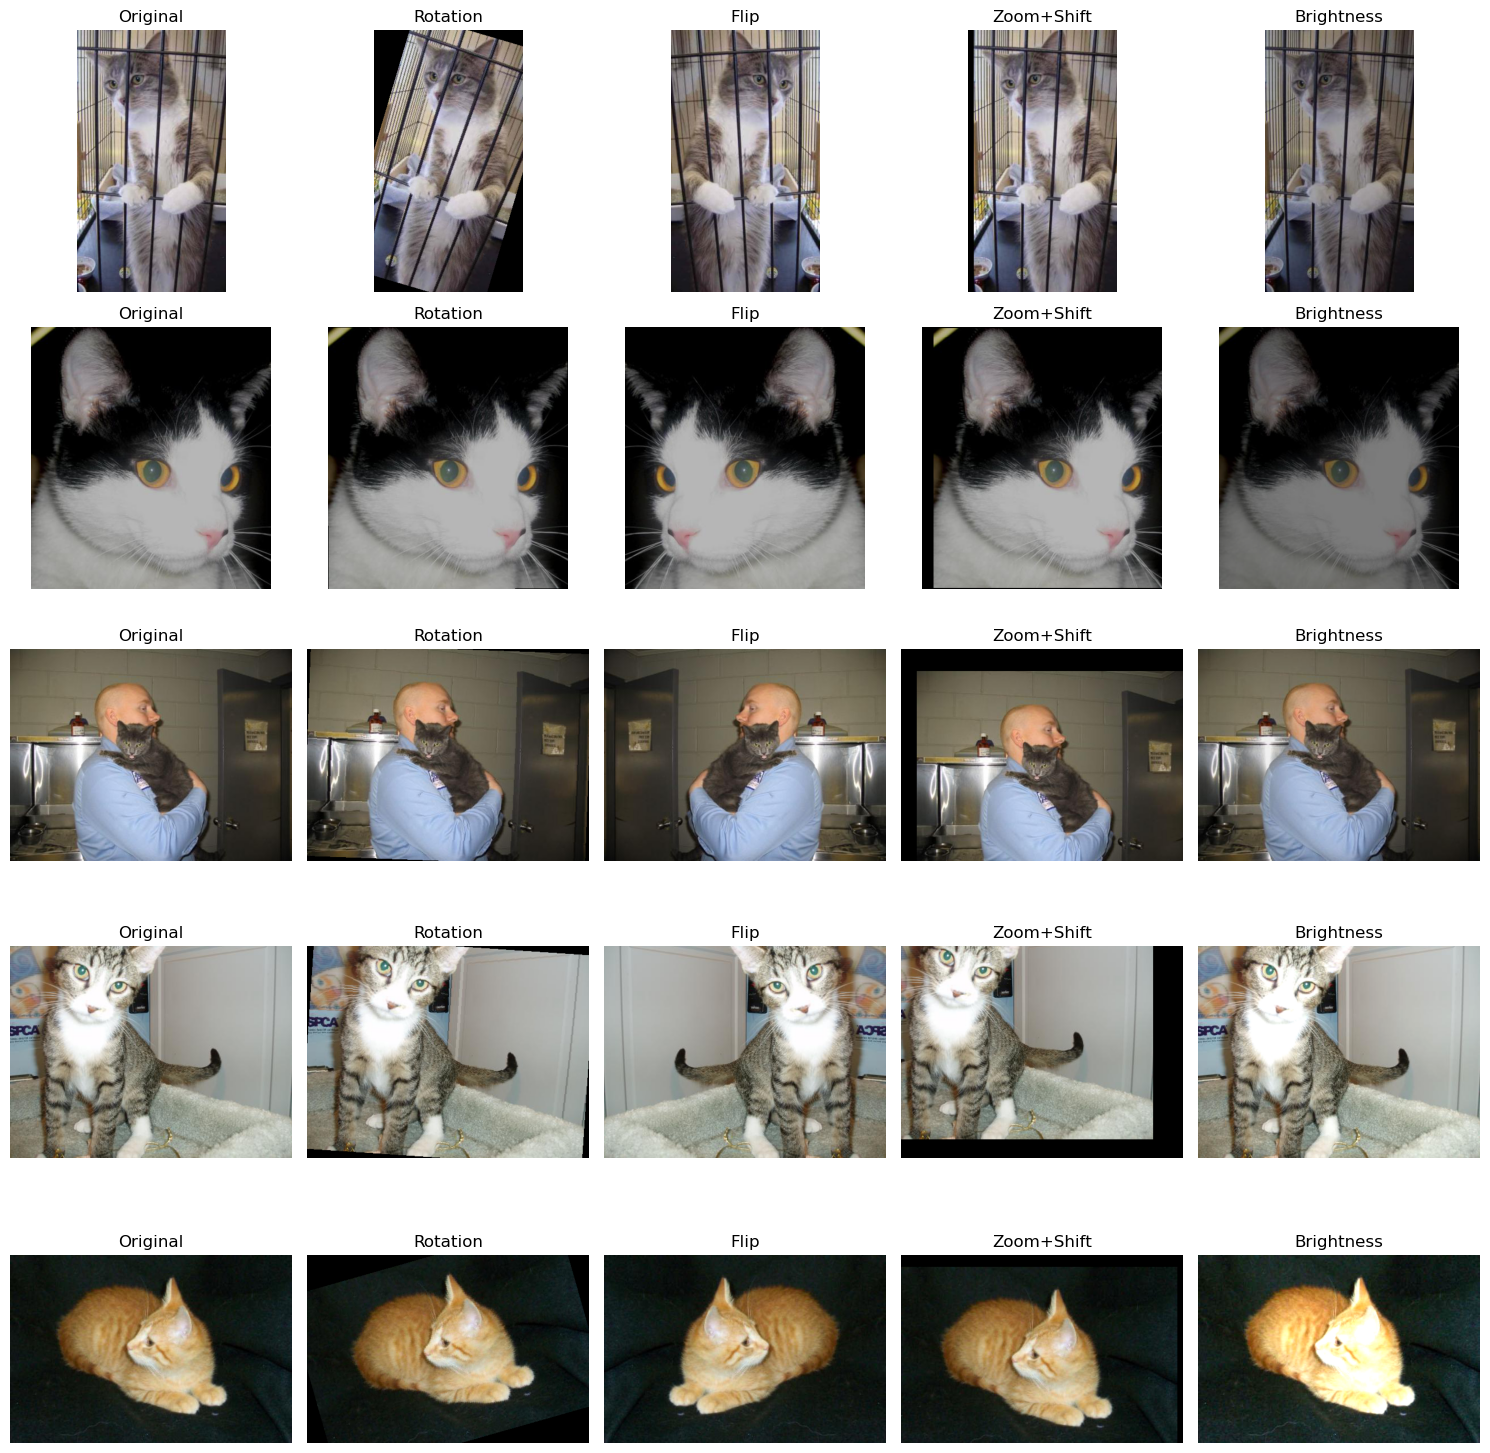

In [11]:
# ==========================================
# Data Augmentation Visualization
# ==========================================


# Cat folder
cat_folder = os.path.join(dataset_dir, "Cat")

# Select 5 random images
img_paths = random.sample(os.listdir(cat_folder), 5)

# Augmentations
rotation = transforms.RandomRotation(20)
flip = transforms.RandomHorizontalFlip(p=1)
zoom_shift = transforms.RandomAffine(
    degrees=0,
    translate=(0.1, 0.1),
    scale=(0.9, 1.1)
)
brightness = transforms.ColorJitter(brightness=0.5)


plt.figure(figsize=(15, 15))

for i, img_name in enumerate(img_paths):

    # Load image
    img_path = os.path.join(cat_folder, img_name)
    image = Image.open(img_path).convert("RGB")

    # Apply augmentation (one example)
    augmented = [
        image,
        rotation(image),
        flip(image),
        zoom_shift(image),
        brightness(image)
    ]

    titles = [
        "Original",
        "Rotation",
        "Flip",
        "Zoom+Shift",
        "Brightness"
    ]

    # Display each image row
    for j in range(5):
        plt.subplot(5, 5, i*5 + j + 1)
        plt.imshow(augmented[j])
        plt.title(titles[j])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
# ==========================================
# Dataset Loading
# ==========================================



dataset = ImageFolder(
    root=dataset_dir,
    transform=train_transform
)

print("Total Images:", len(dataset))
print("Classes:", dataset.classes)

Total Images: 24998
Classes: ['Cat', 'Dog']


In [13]:
# ==========================================
# Label Encoding
# ==========================================

print("Label Encoding:")
print(dataset.class_to_idx)

Label Encoding:
{'Cat': 0, 'Dog': 1}


In [14]:
# ==========================================
# Train, Validation and Test Split
# ==========================================



# 70% Train, 15% Validation, 15% Test
train_size = int(0.70 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

print("Train Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))
print("Test Images:", len(test_dataset))

Train Images: 17498
Validation Images: 3749
Test Images: 3751


In [15]:
# ==========================================
# DataLoader Creation
# ==========================================

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4
)

print("Train Batches:", len(train_loader))
print("Validation Batches:", len(val_loader))
print("Test Batches:", len(test_loader))

Train Batches: 137
Validation Batches: 30
Test Batches: 30


In [16]:
# ==========================================
# Verify DataLoader
# ==========================================

images, labels = next(iter(train_loader))

print("Image Shape :", images.shape)
print("Label Shape :", labels.shape)

print("\nSample Labels:")
print(labels[:10])

Image Shape : torch.Size([128, 3, 224, 224])
Label Shape : torch.Size([128])

Sample Labels:
tensor([0, 1, 0, 0, 1, 1, 0, 0, 0, 0])


In [17]:
# ==========================================
# GPU Check
# ==========================================



print("Torch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
print("CUDA Version:", torch.version.cuda)
print("GPU Count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

Torch Version: 2.6.0+cu124
CUDA Available: True
CUDA Version: 12.4
GPU Count: 1
GPU Name: NVIDIA GeForce RTX 3050


In [18]:
# ==========================================
# AlexNet Transfer Learning
# ==========================================



# Load Pretrained AlexNet
model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)

# Freeze feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Replace final classifier layer
model.classifier[6] = nn.Linear(
    model.classifier[6].in_features,
    2
)

# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer (only train classifier)
optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=0.0001
)

print("Device:", device)
print("Model Ready!")

Device: cuda
Model Ready!


In [24]:
# ==========================================
# Model Training
# ==========================================

num_epochs = 10

for epoch in range(num_epochs):

    model.train()

    correct = 0
    total = 0
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predicted = outputs.argmax(1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Accuracy: {accuracy:.2f}%"
    )

Epoch 1/10 | Loss: 0.0983 | Accuracy: 95.99%
Epoch 2/10 | Loss: 0.0958 | Accuracy: 96.23%
Epoch 3/10 | Loss: 0.0880 | Accuracy: 96.58%
Epoch 4/10 | Loss: 0.0849 | Accuracy: 96.65%
Epoch 5/10 | Loss: 0.0814 | Accuracy: 96.77%
Epoch 6/10 | Loss: 0.0776 | Accuracy: 96.90%
Epoch 7/10 | Loss: 0.0723 | Accuracy: 97.17%
Epoch 8/10 | Loss: 0.0681 | Accuracy: 97.35%
Epoch 9/10 | Loss: 0.0663 | Accuracy: 97.45%
Epoch 10/10 | Loss: 0.0648 | Accuracy: 97.56%


In [29]:
# ==========================================
# Test Evaluation
# ==========================================



model.eval()

all_labels = []
all_preds = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

print("Accuracy :", accuracy_score(all_labels, all_preds))
print("Precision:", precision_score(all_labels, all_preds))
print("Recall   :", recall_score(all_labels, all_preds))
print("F1 Score :", f1_score(all_labels, all_preds))

Accuracy : 0.9520127965875766
Precision: 0.9585798816568047
Recall   : 0.9453580901856764
F1 Score : 0.9519230769230769


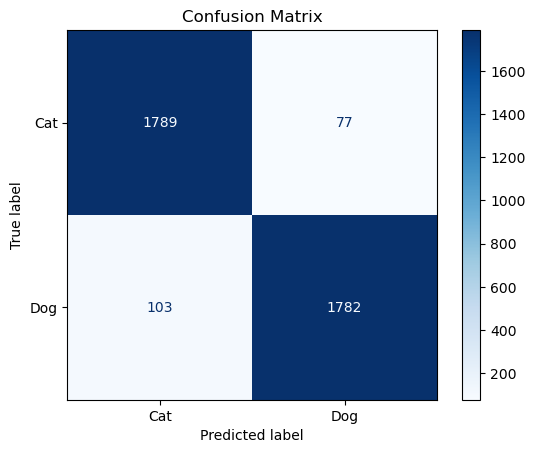

In [30]:
# ==========================================
# Confusion Matrix
# ==========================================



cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat", "Dog"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

AUC Score: 0.9915355332474746


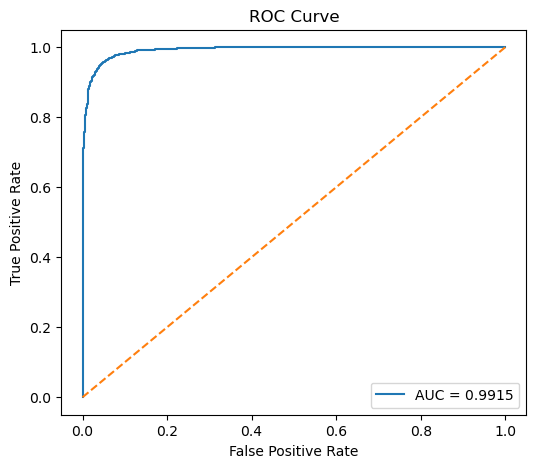

In [31]:
# ==========================================
# ROC Curve and AUC Score
# ==========================================


model.eval()

all_labels_auc = []
all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = F.softmax(outputs, dim=1)

        all_probs.extend(probs[:,1].cpu().numpy())
        all_labels_auc.extend(labels.numpy())

fpr, tpr, _ = roc_curve(all_labels_auc, all_probs)

roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

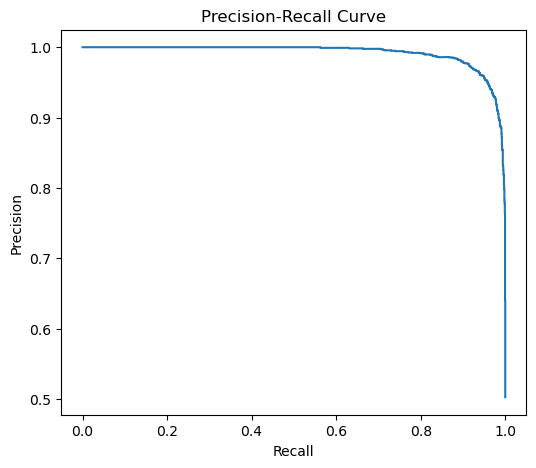

In [32]:
# ==========================================
# Precision-Recall Curve
# ==========================================



precision, recall, _ = precision_recall_curve(
    all_labels_auc,
    all_probs
)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()